# Tugas 2: Pengolahan Citra Digital (PCD_Assignment02)

## Image enhancement untuk empat kondisi citra

Notebook ini mengimplementasikan enhancement pada empat kondisi: blurred image, dark image, bright image, dan low-contrast image. Setiap kondisi diproses dengan metode yang sesuai dengan jenis degradasinya.

Evaluasi membandingkan hasil dengan citra acuan melalui MSE, PSNR, dan SSIM. Brightness, RMS contrast, sharpness, entropy, visual comparison, dan histogram digunakan sebagai analitik tambahan untuk menjelaskan perubahan yang terjadi.

In [1]:
import urllib.request
from pathlib import Path

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.measure import shannon_entropy
from skimage.metrics import structural_similarity

plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 110

print(f"NumPy  : {np.__version__}")
print(f"OpenCV : {cv2.__version__}")

NumPy  : 2.5.3
OpenCV : 5.0.0


## 1. Dasar teori

Image enhancement membuat informasi yang sudah ada di dalam citra lebih mudah diamati. Metode dipilih sesuai degradasi yang diuji.

### A. Blurred image: Unsharp Masking
Unsharp Masking mengambil selisih antara input dan hasil Gaussian blur sebagai komponen detail, lalu menambahkan detail tersebut kembali ke input.

### B. Dark dan bright image: Gamma Correction
Transformasi gamma mengikuti hubungan s = 255(r/255)^gamma. Gamma di bawah 1 menaikkan luminance, sedangkan gamma di atas 1 menurunkannya.

### C. Kontras lokal: CLAHE
Contrast Limited Adaptive Histogram Equalization (CLAHE) bekerja pada area lokal dan membatasi amplifikasi histogram. Pada notebook ini CLAHE diterapkan pada luminance agar equalization tidak dilakukan secara terpisah pada setiap channel RGB.

### D. Low-contrast image: Contrast Stretching
Percentile stretching memetakan percentile bawah dan atas ke rentang intensitas yang lebih lebar. Pemakaian percentile mencegah beberapa nilai ekstrem menentukan seluruh rentang pemetaan.

In [2]:
def _uint8(image):
    return np.clip(image, 0, 255).astype(np.uint8)

def to_gray(image):
    if image.ndim == 2:
        return _uint8(image)
    return cv2.cvtColor(_uint8(image), cv2.COLOR_RGB2GRAY)

def image_statistics(image):
    gray = to_gray(image)
    return {
        "Brightness": float(gray.mean()),
        "RMS_Contrast": float(gray.std()),
        "Sharpness": float(cv2.Laplacian(gray, cv2.CV_64F).var()),
        "Entropy": float(shannon_entropy(gray)),
    }

def gamma_correction(image, gamma):
    x = _uint8(image).astype(np.float32) / 255.0
    return np.clip(np.round(np.power(x, gamma) * 255.0), 0, 255).astype(np.uint8)

def clahe_luminance(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    image = _uint8(image)
    if image.ndim == 2:
        return cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size,
        ).apply(image)

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size,
    ).apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

def enhance_blurred(image, sigma=1.3, amount=1.35):
    image = _uint8(image)
    smooth = cv2.GaussianBlur(image, (0, 0), sigmaX=sigma, sigmaY=sigma)
    return _uint8(cv2.addWeighted(image, 1.0 + amount, smooth, -amount, 0))

def enhance_dark(image):
    corrected = gamma_correction(image, 0.52)
    return clahe_luminance(corrected, clip_limit=1.65)

def enhance_bright(image):
    corrected = gamma_correction(image, 1.95)
    return clahe_luminance(corrected, clip_limit=1.20)

def contrast_stretch(image, low_p=1.0, high_p=99.0):
    image = _uint8(image)
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    lo, hi = np.percentile(l, [low_p, high_p])
    if hi > lo + 1e-6:
        l = np.clip(
            (l.astype(np.float32) - lo) * 255.0 / (hi - lo),
            0,
            255,
        ).astype(np.uint8)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

def enhance_low_contrast(image):
    stretched = contrast_stretch(image)
    return clahe_luminance(stretched, clip_limit=1.35)

def evaluate(reference, test):
    diff = reference.astype(np.float64) - test.astype(np.float64)
    mse = float(np.mean(diff ** 2))
    psnr = float("inf") if mse <= 1e-12 else float(
        20 * np.log10(255.0 / np.sqrt(mse))
    )
    ssim = float(
        structural_similarity(reference, test, channel_axis=-1, data_range=255)
    )
    return {
        "MSE": mse,
        "PSNR_dB": psnr,
        "SSIM": ssim,
        **image_statistics(test),
    }

## 2. Dataset eksperimen

Empat citra acuan dipilih khusus untuk Assignment 02: Coins untuk blur, Hubble Deep Field untuk dark image, Immunohistochemistry untuk bright image, dan Scanned Page untuk low contrast.

Notebook membaca file dari data/input jika tersedia. Saat dijalankan di Colab tanpa folder lokal, file yang sama diambil dari GitHub Raw.

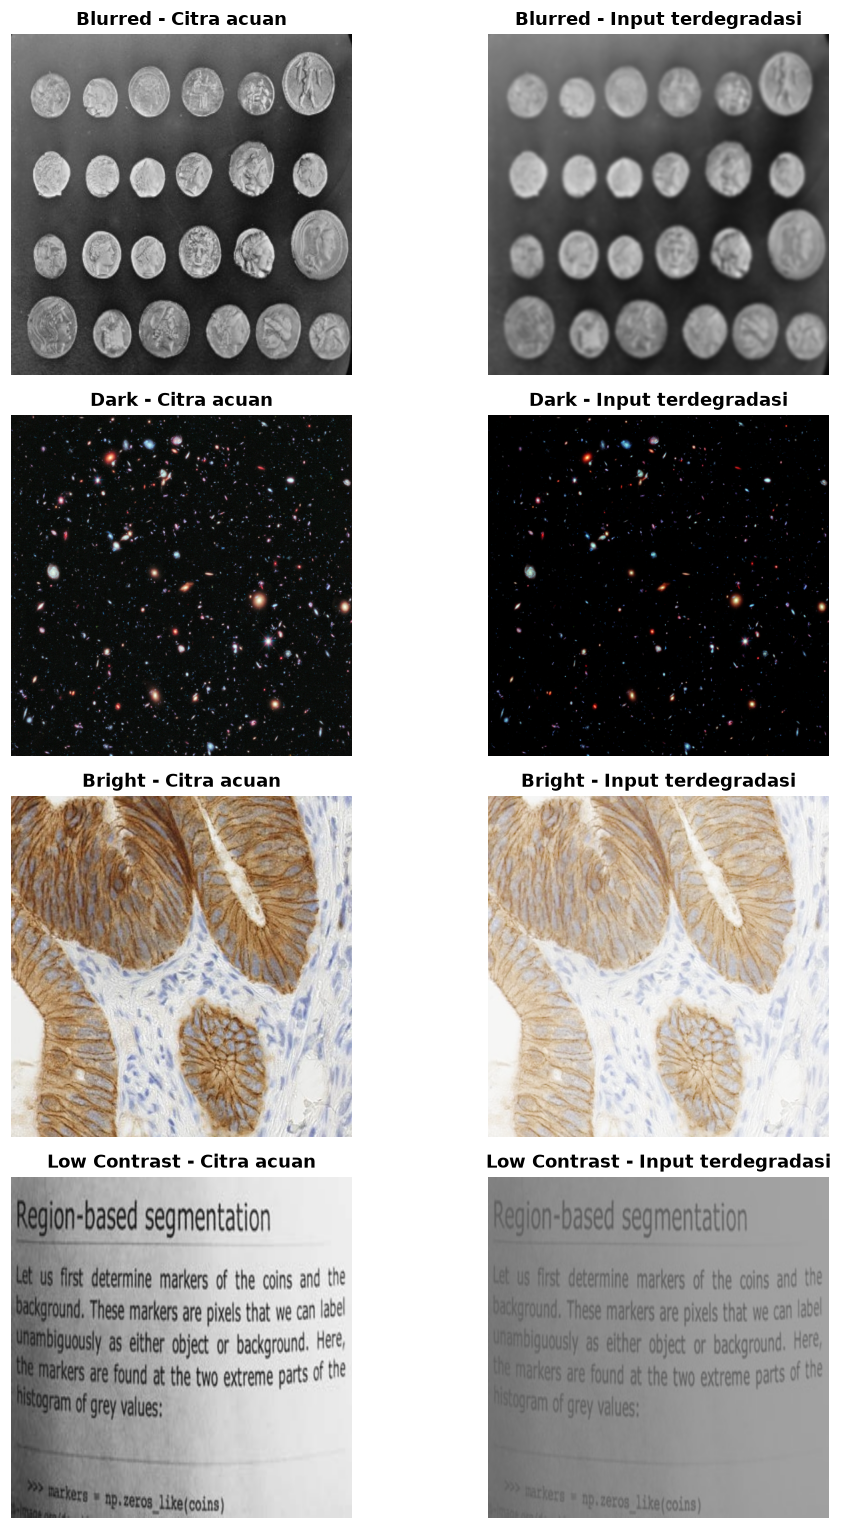

In [3]:
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/hanafishiddiq/PCD_Assignment02/main/data/input"

FILES = {
    "Blurred": ("01_blurred_reference.png", "01_blurred_input.png"),
    "Dark": ("02_dark_reference.png", "02_dark_input.png"),
    "Bright": ("03_bright_reference.png", "03_bright_input.png"),
    "Low Contrast": ("04_low_contrast_reference.png", "04_low_contrast_input.png"),
}

def load_rgb(filename):
    local = Path("data/input") / filename
    if local.exists():
        bgr = cv2.imread(str(local), cv2.IMREAD_COLOR)
    else:
        with urllib.request.urlopen(f"{GITHUB_RAW_BASE}/{filename}") as response:
            raw = np.frombuffer(response.read(), dtype=np.uint8)
        bgr = cv2.imdecode(raw, cv2.IMREAD_COLOR)

    if bgr is None:
        raise FileNotFoundError(filename)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

dataset = {}
for label, (reference_file, input_file) in FILES.items():
    dataset[label] = {
        "reference": load_rgb(reference_file),
        "input": load_rgb(input_file),
    }

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
for row, (label, item) in enumerate(dataset.items()):
    axes[row, 0].imshow(item["reference"])
    axes[row, 0].set_title(f"{label} - Citra acuan", fontweight="bold")
    axes[row, 1].imshow(item["input"])
    axes[row, 1].set_title(f"{label} - Input terdegradasi", fontweight="bold")
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
plt.tight_layout()
plt.show()

## 3. Karakterisasi input

Sebelum enhancement, setiap input diukur menggunakan brightness, RMS contrast, variance of Laplacian sebagai sharpness, dan entropy. Statistik ini tidak memilih metode secara otomatis; fungsinya hanya membantu menjelaskan karakter awal setiap citra.

In [4]:
stats_records = []
for label, item in dataset.items():
    stats_records.append({
        "Condition": label,
        **image_statistics(item["input"]),
    })

stats_df = pd.DataFrame(stats_records)
display(stats_df.round({
    "Brightness": 2,
    "RMS_Contrast": 2,
    "Sharpness": 2,
    "Entropy": 3,
}))

,Condition,Brightness,RMS_Contrast,Sharpness,Entropy
0,Blurred,96.36,48.43,6.23,7.385
1,Dark,3.31,17.01,429.37,1.921
2,Bright,205.95,28.45,172.11,6.604
3,Low Contrast,141.30,17.33,63.10,5.740


## 4. Proses enhancement

Metode diterapkan langsung sesuai kondisi eksperimen yang sudah diketahui:

- Blurred: Unsharp Masking.
- Dark: Gamma Correction + CLAHE.
- Bright: Gamma Correction + CLAHE dengan clip limit lebih rendah.
- Low Contrast: Percentile Contrast Stretching + CLAHE.

Dengan alur ini, notebook berfokus pada implementasi dan analisis enhancement, bukan klasifikasi otomatis jenis degradasi.

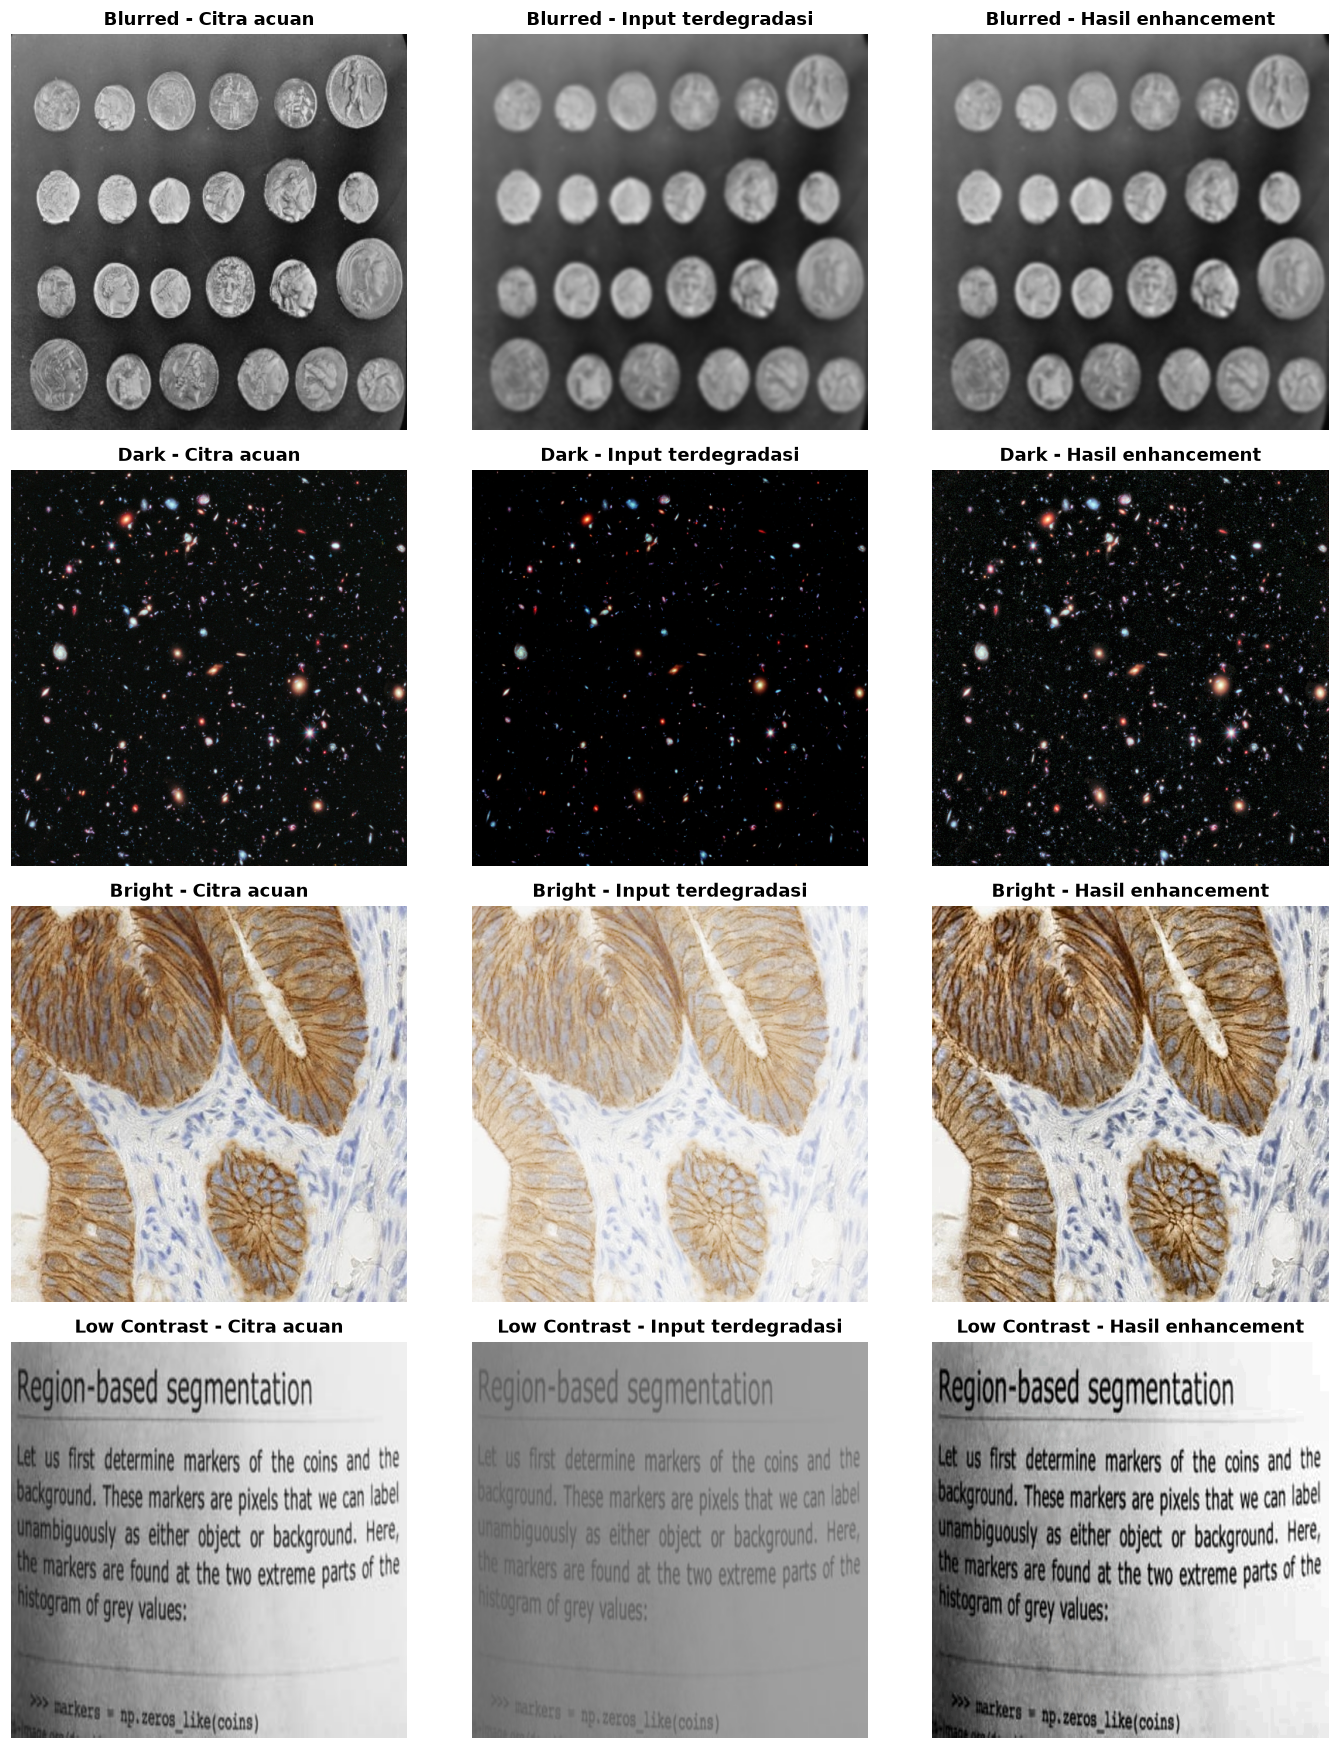

,Condition,Stage,MSE,PSNR_dB,SSIM,Brightness,RMS_Contrast,Sharpness,Entropy
0,Blurred,Degraded,129.56,27.01,0.7928,96.4,48.4,6.2,7.385
1,Blurred,Enhanced,98.04,28.22,0.8287,96.4,49.3,16.8,7.408
2,Dark,Degraded,373.99,22.40,0.1381,3.3,17.0,429.4,1.921
3,Dark,Enhanced,46.67,31.44,0.8117,17.0,28.5,1733.2,3.655
4,Bright,Degraded,2295.46,14.52,0.8591,206.0,28.4,172.1,6.604
5,Bright,Enhanced,236.63,24.39,0.9233,158.2,51.9,911.2,7.584
6,Low Contrast,Degraded,2248.69,14.61,0.8010,141.3,17.3,63.1,5.740
7,Low Contrast,Enhanced,176.85,25.65,0.9523,169.2,66.5,1030.3,7.396


In [5]:
METHODS = {
    "Blurred": enhance_blurred,
    "Dark": enhance_dark,
    "Bright": enhance_bright,
    "Low Contrast": enhance_low_contrast,
}

enhanced = {}
records = []

fig, axes = plt.subplots(4, 3, figsize=(13, 16))
for row, (label, item) in enumerate(dataset.items()):
    output = METHODS[label](item["input"])
    enhanced[label] = output

    for stage, image in [
        ("Degraded", item["input"]),
        ("Enhanced", output),
    ]:
        records.append({
            "Condition": label,
            "Stage": stage,
            **evaluate(item["reference"], image),
        })

    for col, (title, image) in enumerate([
        ("Citra acuan", item["reference"]),
        ("Input terdegradasi", item["input"]),
        ("Hasil enhancement", output),
    ]):
        axes[row, col].imshow(image)
        axes[row, col].set_title(f"{label} - {title}", fontweight="bold")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(records)
display(results_df.round({
    "MSE": 2,
    "PSNR_dB": 2,
    "SSIM": 4,
    "Brightness": 1,
    "RMS_Contrast": 1,
    "Sharpness": 1,
    "Entropy": 3,
}))

## 5. Analisis histogram

Histogram memperlihatkan arah perubahan intensitas. Dark image seharusnya bergeser menjauh dari nilai sangat rendah, bright image kembali dari intensitas tinggi, dan low-contrast image memiliki sebaran yang lebih lebar setelah stretching. Pada blurred image, perubahan utama berada pada detail tepi sehingga histogram global tidak harus berubah besar.

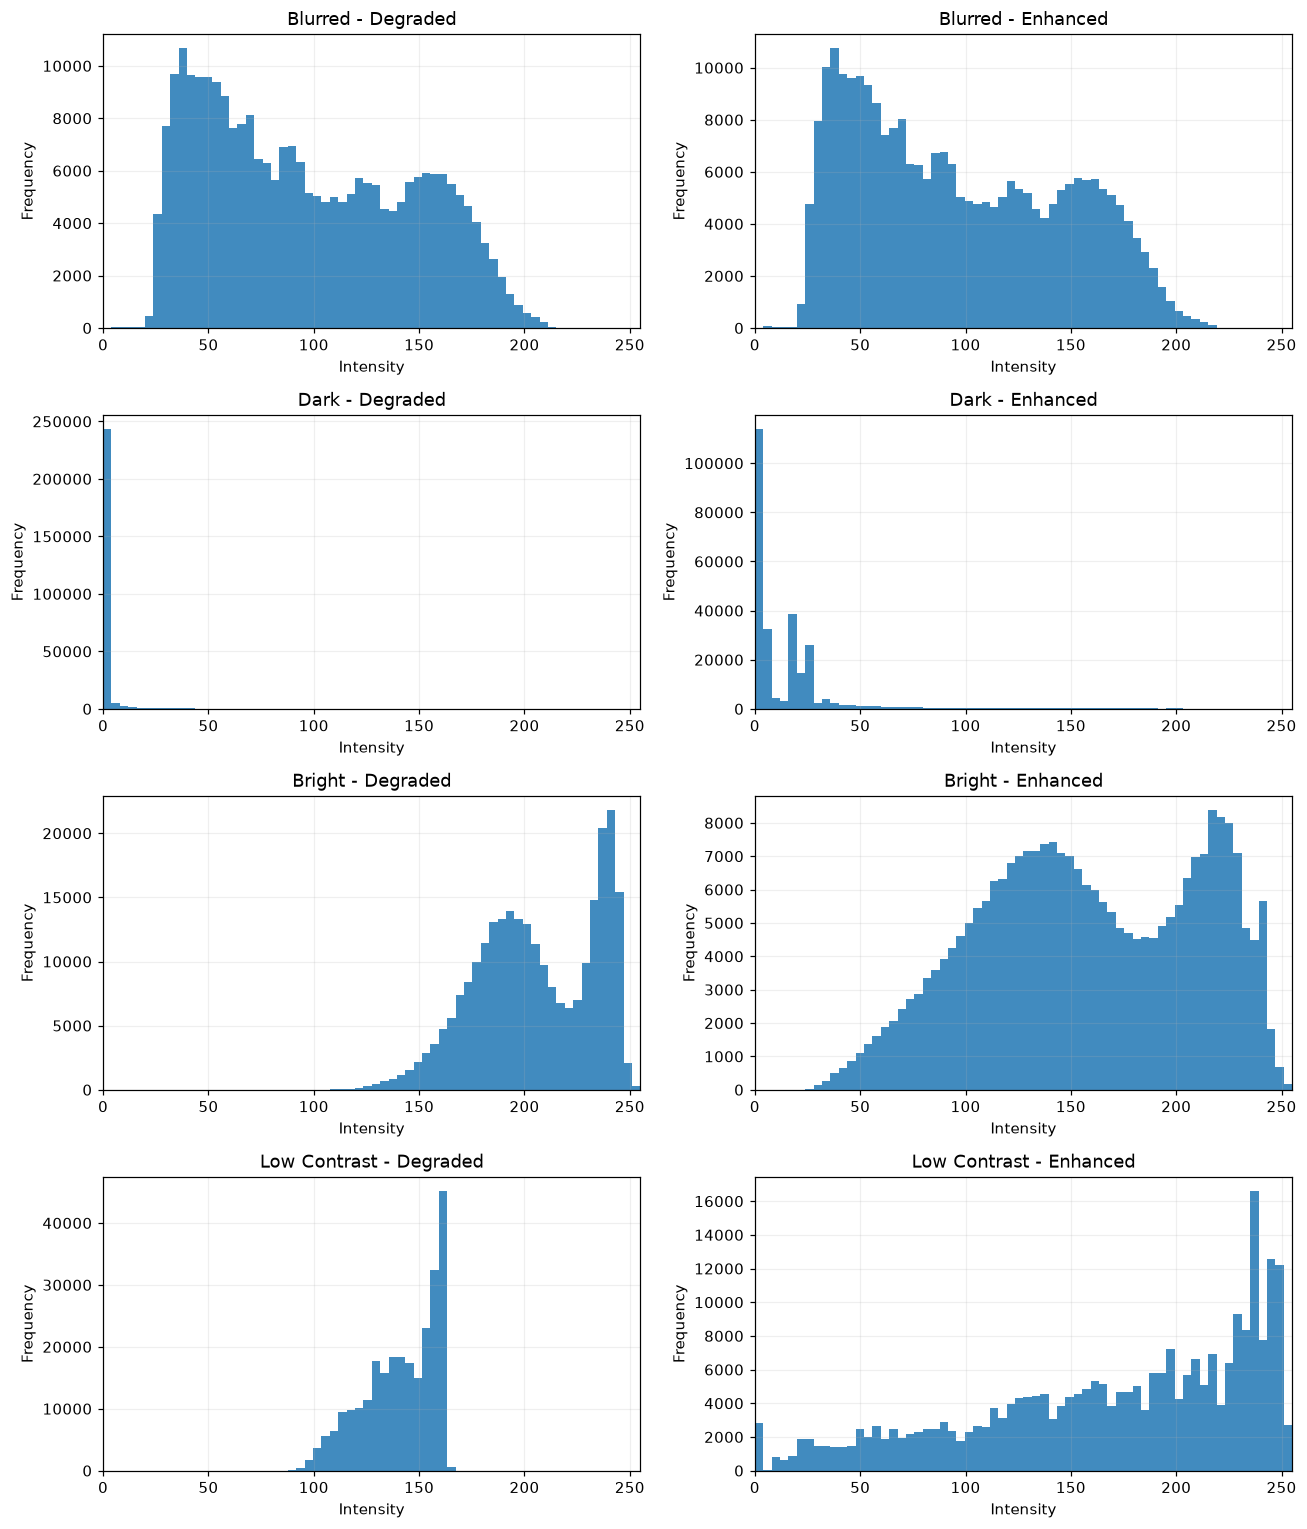

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for row, (label, item) in enumerate(dataset.items()):
    for col, (stage, image) in enumerate([
        ("Degraded", item["input"]),
        ("Enhanced", enhanced[label]),
    ]):
        gray = to_gray(image)
        axes[row, col].hist(gray.ravel(), bins=64, range=(0, 255), alpha=0.85)
        axes[row, col].set_xlim(0, 255)
        axes[row, col].set_title(f"{label} - {stage}")
        axes[row, col].set_xlabel("Intensity")
        axes[row, col].set_ylabel("Frequency")
        axes[row, col].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Evaluasi kuantitatif

MSE mengukur rata-rata kuadrat selisih piksel terhadap citra acuan. PSNR yang lebih tinggi menunjukkan error intensitas yang lebih kecil, sedangkan SSIM yang mendekati 1 menunjukkan struktur yang lebih mirip dengan acuan.

Brightness, RMS contrast, sharpness, dan entropy dipakai sebagai metrik penjelas. Nilai yang lebih besar pada metrik tersebut tidak selalu berarti kualitas yang lebih baik.

,Condition,PSNR Before,PSNR After,Delta PSNR,SSIM Before,SSIM After,Delta SSIM
0,Blurred,27.0060,28.2167,1.2108,0.7928,0.8287,0.0359
1,Dark,22.4022,31.4406,9.0385,0.1381,0.8117,0.6736
2,Bright,14.5221,24.3901,9.8680,0.8591,0.9233,0.0642
3,Low Contrast,14.6115,25.6546,11.0431,0.8010,0.9523,0.1513


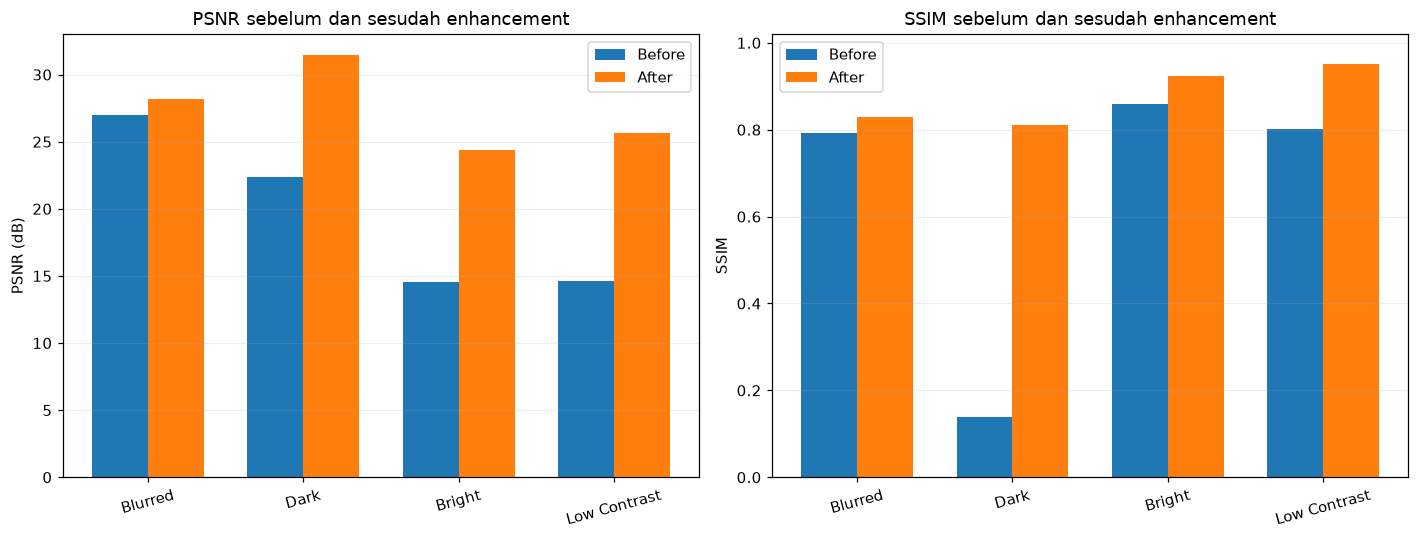

In [7]:
summary = []
for label in dataset:
    degraded = results_df[
        (results_df.Condition == label) & (results_df.Stage == "Degraded")
    ].iloc[0]
    enhanced_row = results_df[
        (results_df.Condition == label) & (results_df.Stage == "Enhanced")
    ].iloc[0]

    summary.append({
        "Condition": label,
        "PSNR Before": degraded.PSNR_dB,
        "PSNR After": enhanced_row.PSNR_dB,
        "Delta PSNR": enhanced_row.PSNR_dB - degraded.PSNR_dB,
        "SSIM Before": degraded.SSIM,
        "SSIM After": enhanced_row.SSIM,
        "Delta SSIM": enhanced_row.SSIM - degraded.SSIM,
    })

summary_df = pd.DataFrame(summary)
display(summary_df.round(4))

x = np.arange(len(summary_df))
width = 0.36
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - width / 2, summary_df["PSNR Before"], width, label="Before")
axes[0].bar(x + width / 2, summary_df["PSNR After"], width, label="After")
axes[0].set_xticks(x, summary_df["Condition"], rotation=15)
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR sebelum dan sesudah enhancement")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(x - width / 2, summary_df["SSIM Before"], width, label="Before")
axes[1].bar(x + width / 2, summary_df["SSIM After"], width, label="After")
axes[1].set_xticks(x, summary_df["Condition"], rotation=15)
axes[1].set_ylabel("SSIM")
axes[1].set_ylim(0, 1.02)
axes[1].set_title("SSIM sebelum dan sesudah enhancement")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Analisis hasil

Pada kondisi Blurred, PSNR berubah dari 27.01 menjadi 28.22 dB dan SSIM dari 0.7928 menjadi 0.8287. Brightness berubah dari 96.4 menjadi 96.4, sedangkan RMS contrast berubah dari 48.4 menjadi 49.3.

Pada kondisi Dark, PSNR berubah dari 22.40 menjadi 31.44 dB dan SSIM dari 0.1381 menjadi 0.8117. Brightness berubah dari 3.3 menjadi 17.0, sedangkan RMS contrast berubah dari 17.0 menjadi 28.5.

Pada kondisi Bright, PSNR berubah dari 14.52 menjadi 24.39 dB dan SSIM dari 0.8591 menjadi 0.9233. Brightness berubah dari 206.0 menjadi 158.2, sedangkan RMS contrast berubah dari 28.4 menjadi 51.9.

Pada kondisi Low Contrast, PSNR berubah dari 14.61 menjadi 25.65 dB dan SSIM dari 0.8010 menjadi 0.9523. Brightness berubah dari 141.3 menjadi 169.2, sedangkan RMS contrast berubah dari 17.3 menjadi 66.5.

Pada blur, kenaikan sharpness harus dibaca bersama PSNR dan SSIM karena penajaman berlebihan dapat menghasilkan halo. Pada dark dan bright image, koreksi gamma mengembalikan luminance ke rentang yang lebih dekat dengan citra acuan, lalu CLAHE menambah kontras lokal. Pada low contrast, stretching memperlebar rentang intensitas sehingga pemisahan objek meningkat.

Eksperimen ini memiliki citra acuan karena degradasi dibentuk dari citra bersih. Pada foto nyata, citra acuan biasanya tidak tersedia sehingga evaluasi dapat menggunakan statistik no-reference dan inspeksi visual.

## 8. Kesimpulan

Keempat benchmark memperoleh PSNR dan SSIM yang lebih tinggi setelah enhancement. Metode yang dipakai berbeda karena degradasinya berbeda: Unsharp Masking untuk blur, Gamma Correction + CLAHE untuk masalah exposure, dan Percentile Contrast Stretching + CLAHE untuk kontras rendah.

Perbaikan pada dark, bright, dan low-contrast image lebih besar daripada pada blur. Gaussian blur telah membuang sebagian informasi frekuensi tinggi, sedangkan transformasi tonal pada tiga kondisi lain masih menyimpan lebih banyak struktur yang dapat dipulihkan.